In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/linear-regression-assumptions/refs/heads/main/data.csv')
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

In [4]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# Residual

y_pred = model.predict(X_test)
residual = y_test - y_pred

## 1. Linear Relationship

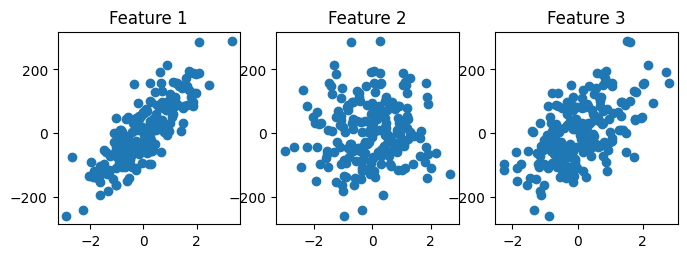

In [21]:
fig ,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(8,2.5))

ax1.scatter(df['feature1'],df['target'])
ax1.set_title("Feature 1")
ax2.scatter(df['feature2'],df['target'])
ax2.set_title("Feature 2")
ax3.scatter(df['feature3'],df['target'])
ax3.set_title("Feature 3")

plt.show()

## 2. MultiCollinearity

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train,i))

In [25]:
pd.DataFrame({'vif':vif},index=df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.003482,1.005274,1.006564


 for values > 5 data correspond to Multicollinearity

<Axes: >

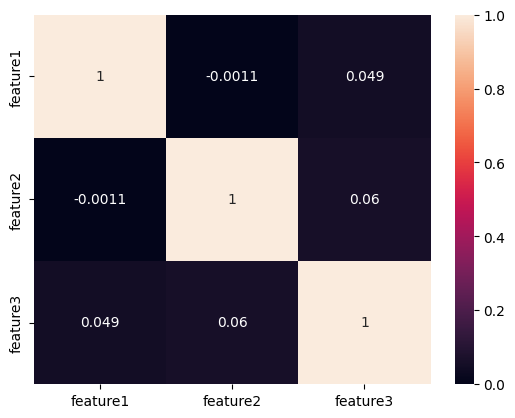

In [26]:
# Another Techique
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

## Normality of Residual

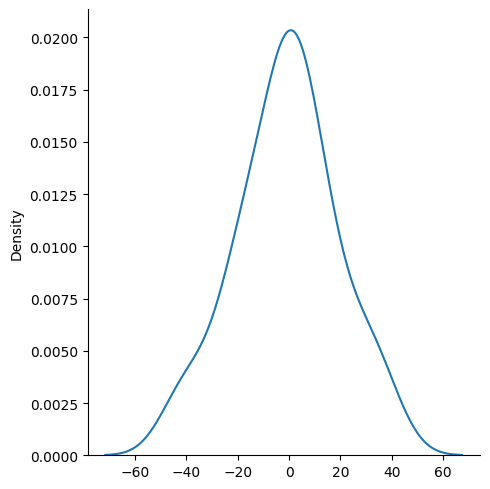

In [28]:
sns.displot(residual,kind='kde')

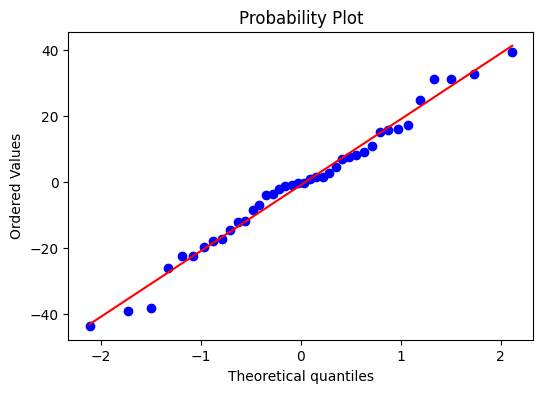

In [30]:
# QQ plot

import scipy as sp

fig , ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual , plot =ax , fit = True)

plt.show()

## 4. Homoscedasticity

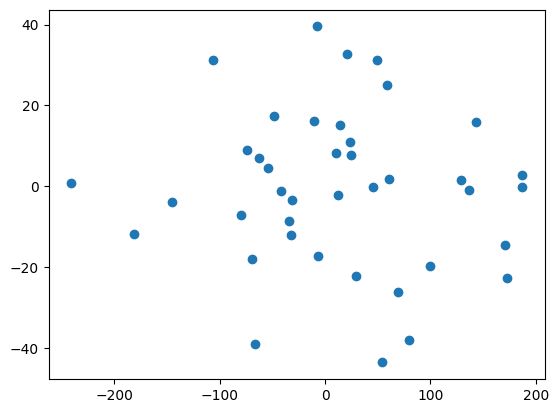

In [31]:
plt.scatter(y_pred , residual)

Spread is nearliy uniform ( same distances covered in X and Y axes )

## 5. No Autocorrelation of Residuals

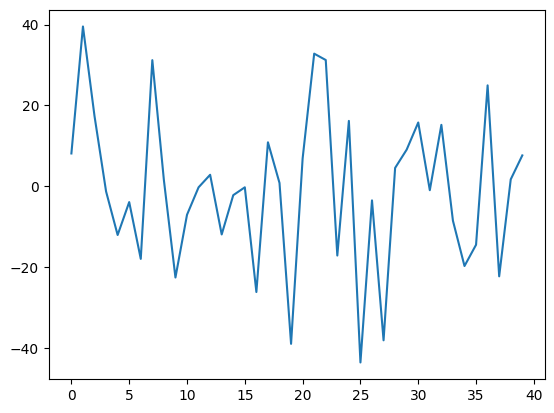

In [33]:
plt.plot(residual)